In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.offsetbox as offsetbox
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import FancyArrowPatch
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from scipy.spatial import Voronoi, voronoi_plot_2d
import numpy as np
from shapely.geometry import LineString
from shapely.geometry import LineString, Point
import pandas as pd
import polars as pl
from matplotlib.colors import ListedColormap

In [ ]:


# -------------------------------------------------------------------
# Paths
# -------------------------------------------------------------------
main_path = '/Users/anzony.quisperojas/Library/CloudStorage/Dropbox/sa_fires/proj_bureaucrats_farms'
csv_path  = f'{main_path}/data_output/intermediate/0_master_merge_data_gen.csv'
out_path  = f'{main_path}/tex/paper/figures/panelview_self_profession.png'

sel_cols = ['unique_small_grid_id', 'monthyear', 'self_profession']

# -------------------------------------------------------------------
# Load only the columns we need; replace NA in self_profession with 0
# -------------------------------------------------------------------
df1 = (
    pl.read_csv(csv_path, columns=sel_cols)
      .with_columns(pl.col('self_profession').fill_null(0).cast(pl.Int8))
)

# -------------------------------------------------------------------
# Pivot to wide: rows = grids, cols = monthyear, values = self_profession
# -------------------------------------------------------------------
wide = df1.pivot(
    index='unique_small_grid_id',
    on='monthyear',
    values='self_profession',
    aggregate_function='max',   # in case of dupes; max keeps any 1 over a 0
)

# Sort grid rows for a consistent y-axis
wide = wide.sort('unique_small_grid_id')



In [8]:
# Sort columns chronologically. Adjust the parser if monthyear isn't YYYY-MM.
out_path  = f'{main_path}/tex/paper/figures/panelview_self_profession.png'
month_cols = [c for c in wide.columns if c != 'unique_small_grid_id']
month_cols_sorted = sorted(month_cols)

grid_ids = wide['unique_small_grid_id'].to_list()
matrix = wide.select(month_cols_sorted).to_numpy().astype(float)

# Any cells that are still NaN (grid never observed in that month) → 0
matrix = np.nan_to_num(matrix, nan=0.0)

# -------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------
n_rows, n_cols = matrix.shape

# Light blue for 0, blue for 1
cmap = ListedColormap(['#cfe2f3', '#1f77b4'])

fig_height = max(6, n_rows * 0.02)   # scale with number of grids
fig_width  = max(10, n_cols * 0.06)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

ax.imshow(
    matrix,
    aspect='auto',
    cmap=cmap,
    vmin=0, vmax=1,
    interpolation='nearest',
)

# X-axis: thin out tick labels so they're readable
n_xticks = min(20, n_cols)
xtick_idx = np.linspace(0, n_cols - 1, n_xticks, dtype=int)
ax.set_xticks(xtick_idx)
ax.set_xticklabels([month_cols_sorted[i] for i in xtick_idx], rotation=45, ha='right')

# Y-axis: thin out grid labels too (usually too many to show all)
n_yticks = min(30, n_rows)
ytick_idx = np.linspace(0, n_rows - 1, n_yticks, dtype=int)
ax.set_yticks(ytick_idx)
ax.set_yticklabels([grid_ids[i] for i in ytick_idx], fontsize=7)

ax.set_xlabel('Month-Year', fontsize=12)
ax.set_ylabel('Grid ID', fontsize=12)
ax.set_title('Panel view: self_profession over time', fontsize=14)

# Legend
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='#1f77b4', edgecolor='black', label='self_profession = 1'),
    Patch(facecolor='#cfe2f3', edgecolor='black', label='self_profession = 0'),
]
ax.legend(handles=legend_elems, loc='upper right', bbox_to_anchor=(1.0, -0.08), ncol=2, frameon=False)

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.close()

print(f'Saved panelview plot to: {out_path}')
print(f'Matrix shape: {n_rows} grids × {n_cols} month-years')

Saved panelview plot to: /Users/anzony.quisperojas/Library/CloudStorage/Dropbox/sa_fires/proj_bureaucrats_farms/tex/paper/figures/panelview_self_profession.png
Matrix shape: 100254 grids × 148 month-years


In [4]:
df1.columns

['election_year',
 'ac_uq_id',
 'province',
 'year',
 'month',
 'unique_small_grid_id',
 'country',
 'district',
 'distr_id',
 'downup_dummy',
 'downup_pop',
 'cellid_wind',
 'id',
 'split_d',
 'split',
 'longitude',
 'latitude',
 'wind_speed_av_cellid_month',
 'wind_direction',
 'av_wind_speed',
 'rollav_wind_direction_cellid_month',
 'count',
 'mean_brightness',
 'dist_id_time',
 'ac_uq_id_only_ac',
 'downup_ac',
 'downup_ac_pop',
 'downwind_area_ac_nosmall',
 'upwind_area_ac_nosmall',
 'total_area',
 'downup_diff',
 'downup_1sd',
 'down_percent',
 'downup_diff_percent',
 'treat.level.5',
 'treat.level.10',
 'D_protest_absor',
 'nlevels',
 'nlevels_actors',
 'ac_hw',
 'acc.protest',
 'protest.achw.downup',
 'protestlvl.achw.downup',
 'acc.protest.actors',
 'actors.achw.downup',
 'monthyear',
 'STATE_UT',
 'DISTRICT',
 'ASSEMBLY_1',
 'ASSEMBLY',
 'acpost08ID',
 'areakm2',
 'rice_area_ha',
 'rice_harvarea_ha',
 'rice_prod_mt',
 'rice_area_ha_share',
 'rice_area_aclvl_ahigh',
 'rice_har

In [2]:
acs = gpd.read_file('../data_output/intermediate/_0_2_3_ACs_right_shapefile.shp')

In [3]:
grid = gpd.read_file( f"../../proj_downwind/data_output/intermediate/1-grid-generation.shp" )
polygons = gpd.read_file( f'../../data/input/ac_boundaries/Constituencies_Boundaries_Post_2008.shp' )


In [4]:

# Selecting States
sel_states = ["PUNJAB", "HARYANA",  "UTTAR PRADESH",  "BIHAR"]
sel_states_shp = polygons[ polygons.STATE_UT.isin( sel_states ) ]



In [5]:
import polars as pl

# 1. Load the data
file_path = r"../data_output/intermediate/0_master_merge_data_gen.csv"
df = pl.read_csv(file_path, ignore_errors=True)
# 2. Filter
df_filtered = df.filter(
    (pl.col("month") == 12) &
    (pl.col("year") == 2020)
)

In [6]:
selgrids = df_filtered[['unique_small_grid_id']].to_pandas()

In [7]:
grid.columns = ['id', 'split_d', 'split', 'unique_small_grid_id', 'geometry']

In [8]:
grid_sel_shp = grid.merge(selgrids)

In [13]:
# high and low rice production -- quintiles
ricea_pr = pd.read_csv(r"../../data/input/crop-production-2010-mapspam/spam2010v2r0_global_prod.csv/spam2010V2r0_global_P_TA.csv", 
                        encoding="windows-1252", usecols=["x", "y", "rice_a"])

In [14]:
gdf = gpd.GeoDataFrame(
    ricea_pr,
    geometry=gpd.points_from_xy(ricea_pr["x"], ricea_pr["y"]),
    crs="EPSG:4326"  # assuming lon/lat
)

In [15]:
ricea_pr_in_acs = gpd.sjoin(gdf, acs, how="inner", predicate="within")
ricea_pr_in_acs.shape

(5642, 11)

<Axes: >

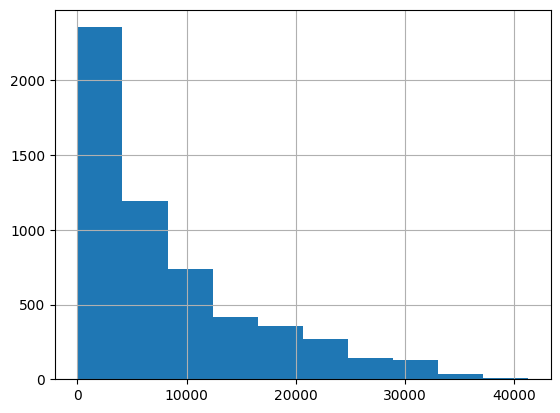

In [16]:
ricea_pr_in_acs['rice_a'].hist()

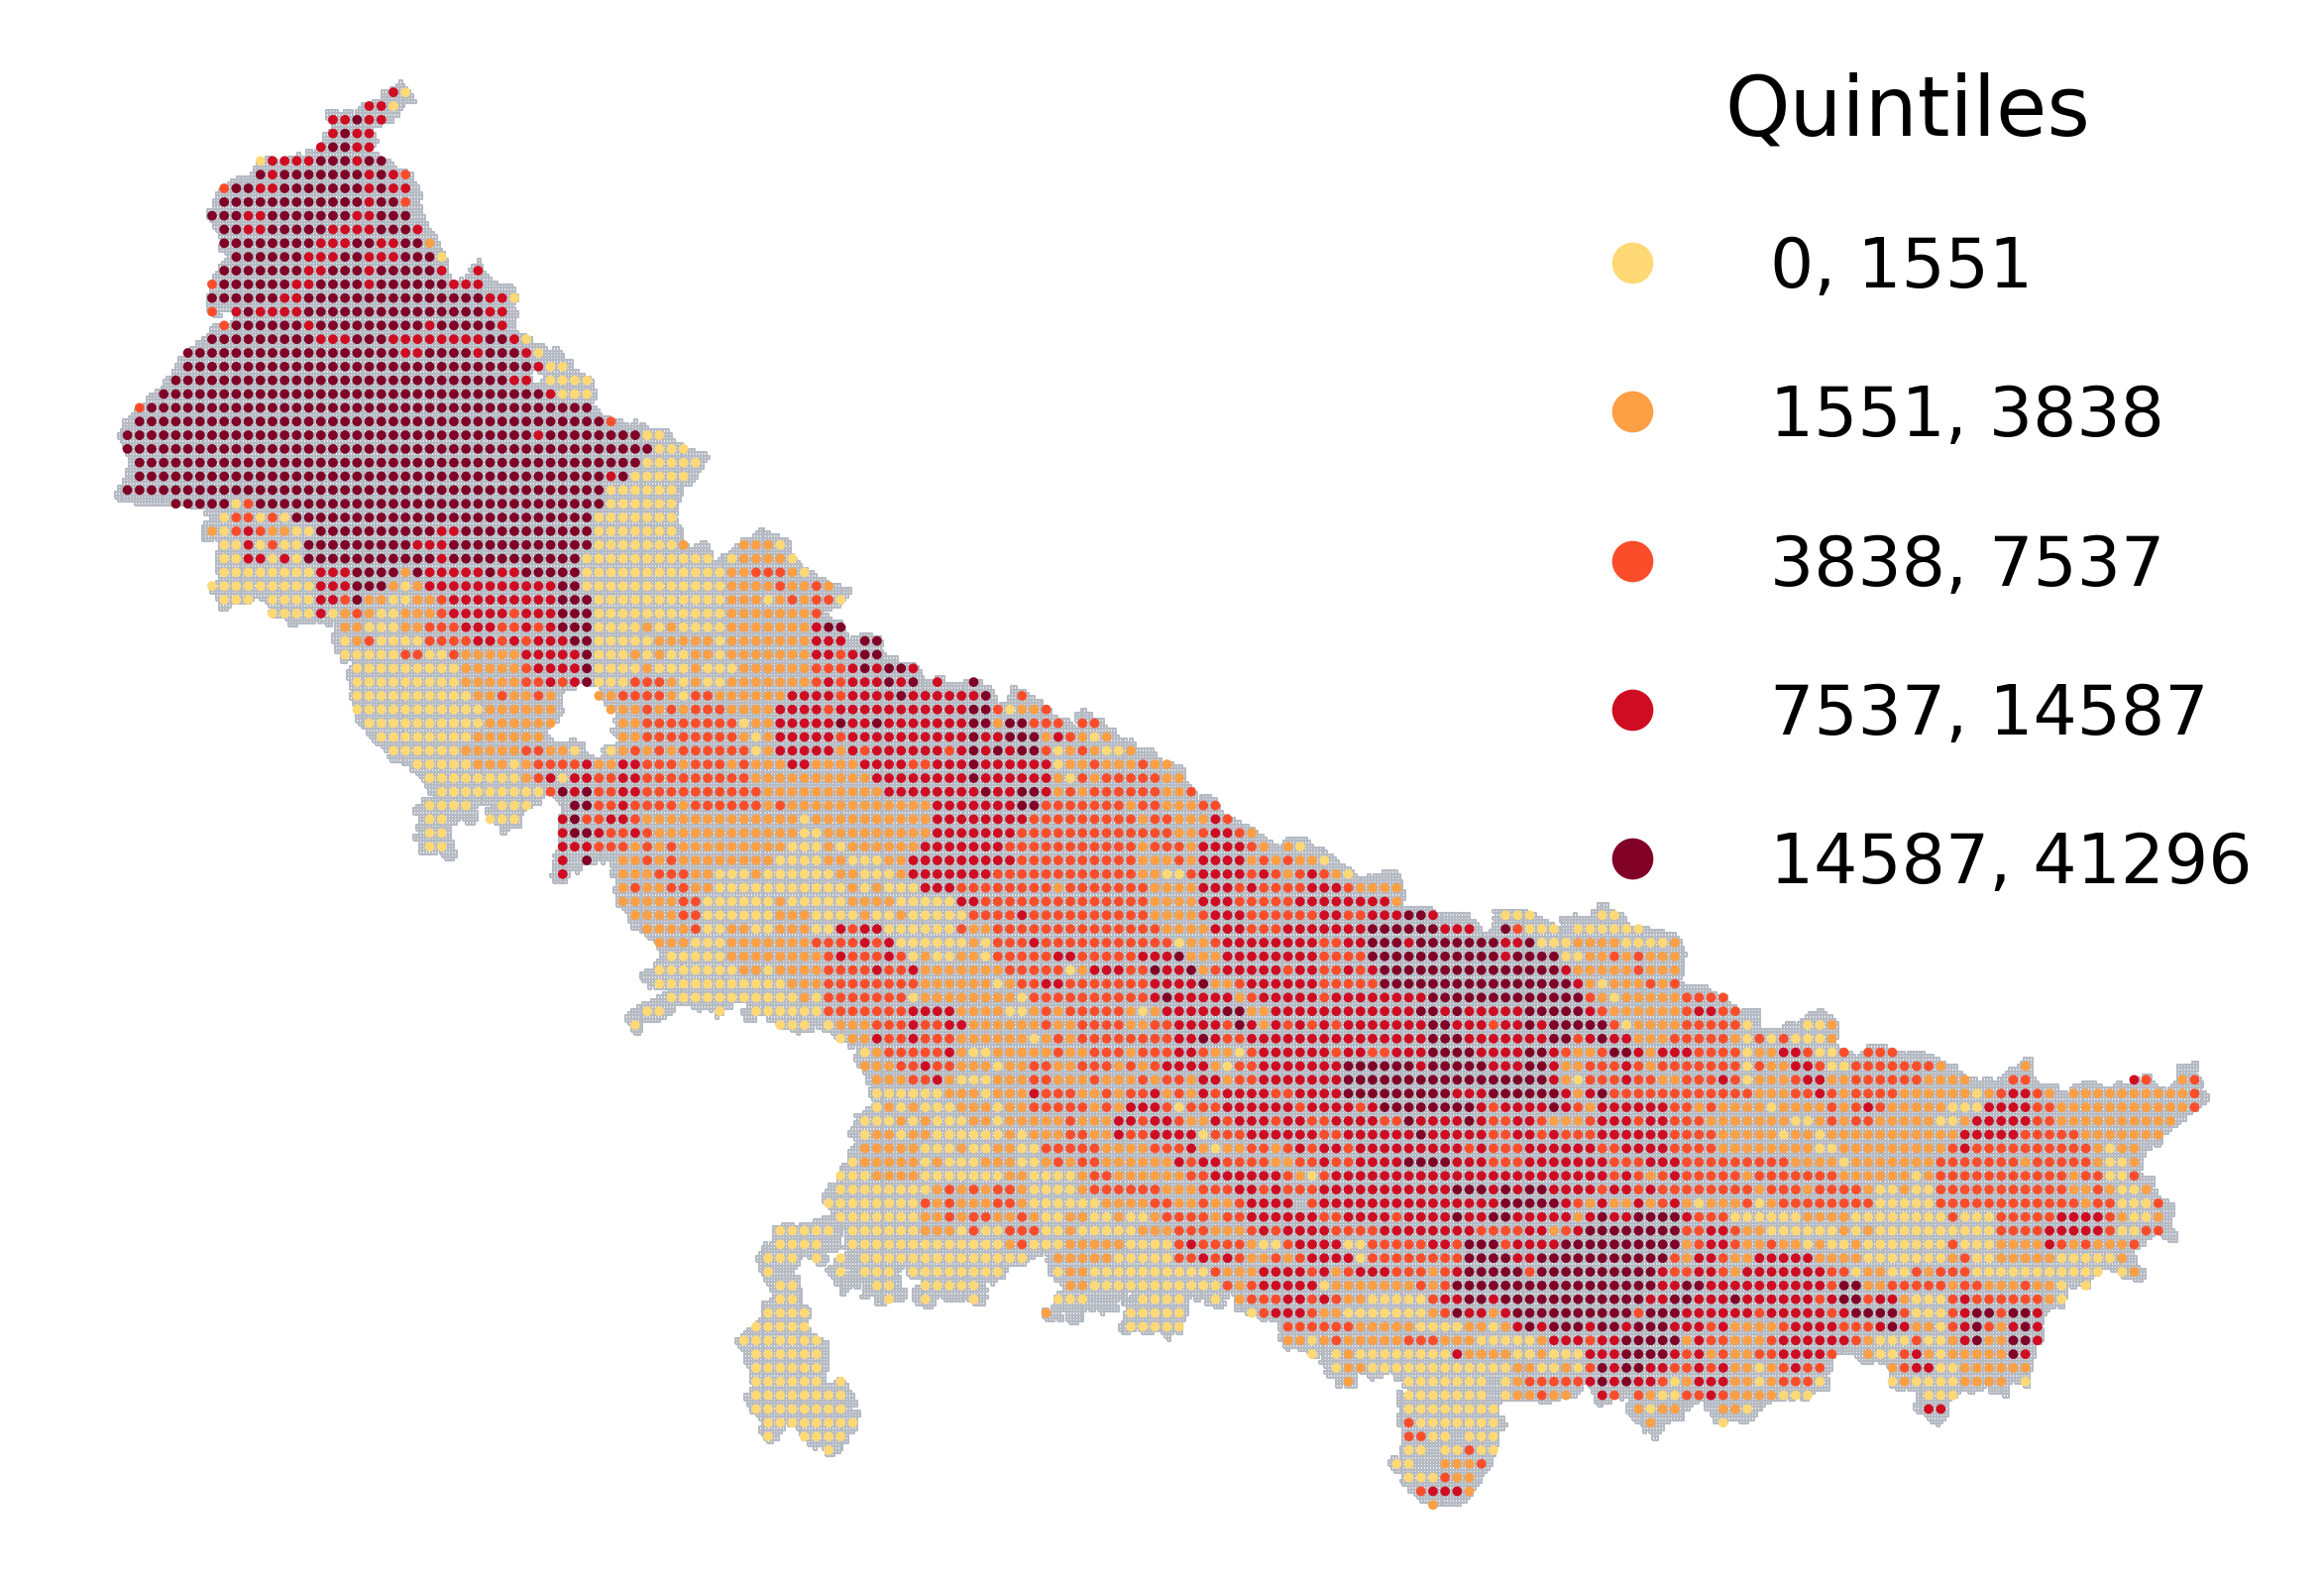

In [32]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrowPatch

# Set up the main plot
fig, ax = plt.subplots(figsize=(30, 30))

# Plot sel_states_shp with grey fill and no edge
grid_sel_shp.boundary.plot(ax=ax, color="#b5bac3", edgecolor=None, zorder=1)

# Plot polygons colored by quintiles of <YOUR_COLUMN>
base = plt.get_cmap("YlOrRd")
trimmed_cmap = LinearSegmentedColormap.from_list(
    "YlOrRd_trim", base(np.linspace(0.25, 1.0, 256))
)
ricea_pr_in_acs.plot(
    ax=ax,
    column="rice_a",
    scheme="quantiles",
    k=5,
    cmap=trimmed_cmap,
    legend=True,
    legend_kwds={
        "title": "Quintiles",
        "loc": "upper right",
        "fontsize": 50,
        "title_fontsize": 60,
        "frameon": False,
        "markerscale": 3,
        "labelspacing": 1.2,
        "handletextpad": 1.0,
    },
    edgecolor=None,
    zorder=10,
)

# Reformat legend labels to remove decimals
leg = ax.get_legend()
for txt in leg.get_texts():
    label = txt.get_text()
    # Labels look like "1.23, 4.56" — split, round, rejoin
    parts = [str(int(round(float(x)))) for x in label.split(",")]
    txt.set_text(", ".join(parts))

ax.axis('off')

# Save
fig.savefig(
    "../tex/paper/figures/rices_grids.pdf",
    format='pdf', dpi=300, bbox_inches='tight'
)

plt.show()

In [51]:
# acs_up = acs.query('STATE_UT == "UTTAR PRADESH"')

# acs_up["centroid"] = acs_up.geometry.centroid

# # Plot polygons
# fig, ax = plt.subplots(figsize=(10, 8))
# acs_up.plot(ax=ax, edgecolor='black', facecolor='none')

# # Add labels at centroids
# for idx, row in acs_up.iterrows():
#     ax.annotate(
#         text=row["ac_uq_id"],
#         xy=(row["centroid"].x, row["centroid"].y),
#         ha="center", va="center",
#         fontsize=6
#     )

# ax.set_axis_off()
# plt.tight_layout()
# plt.show()

In [6]:
# Selecting polygon
sel_polygon = acs.query('ac_uq_id == 780').copy()

C:\Users\rjbar\AppData\Local\Temp\ipykernel_27132\3374710492.py:60: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_acs.geometry.centroid.iloc[0]


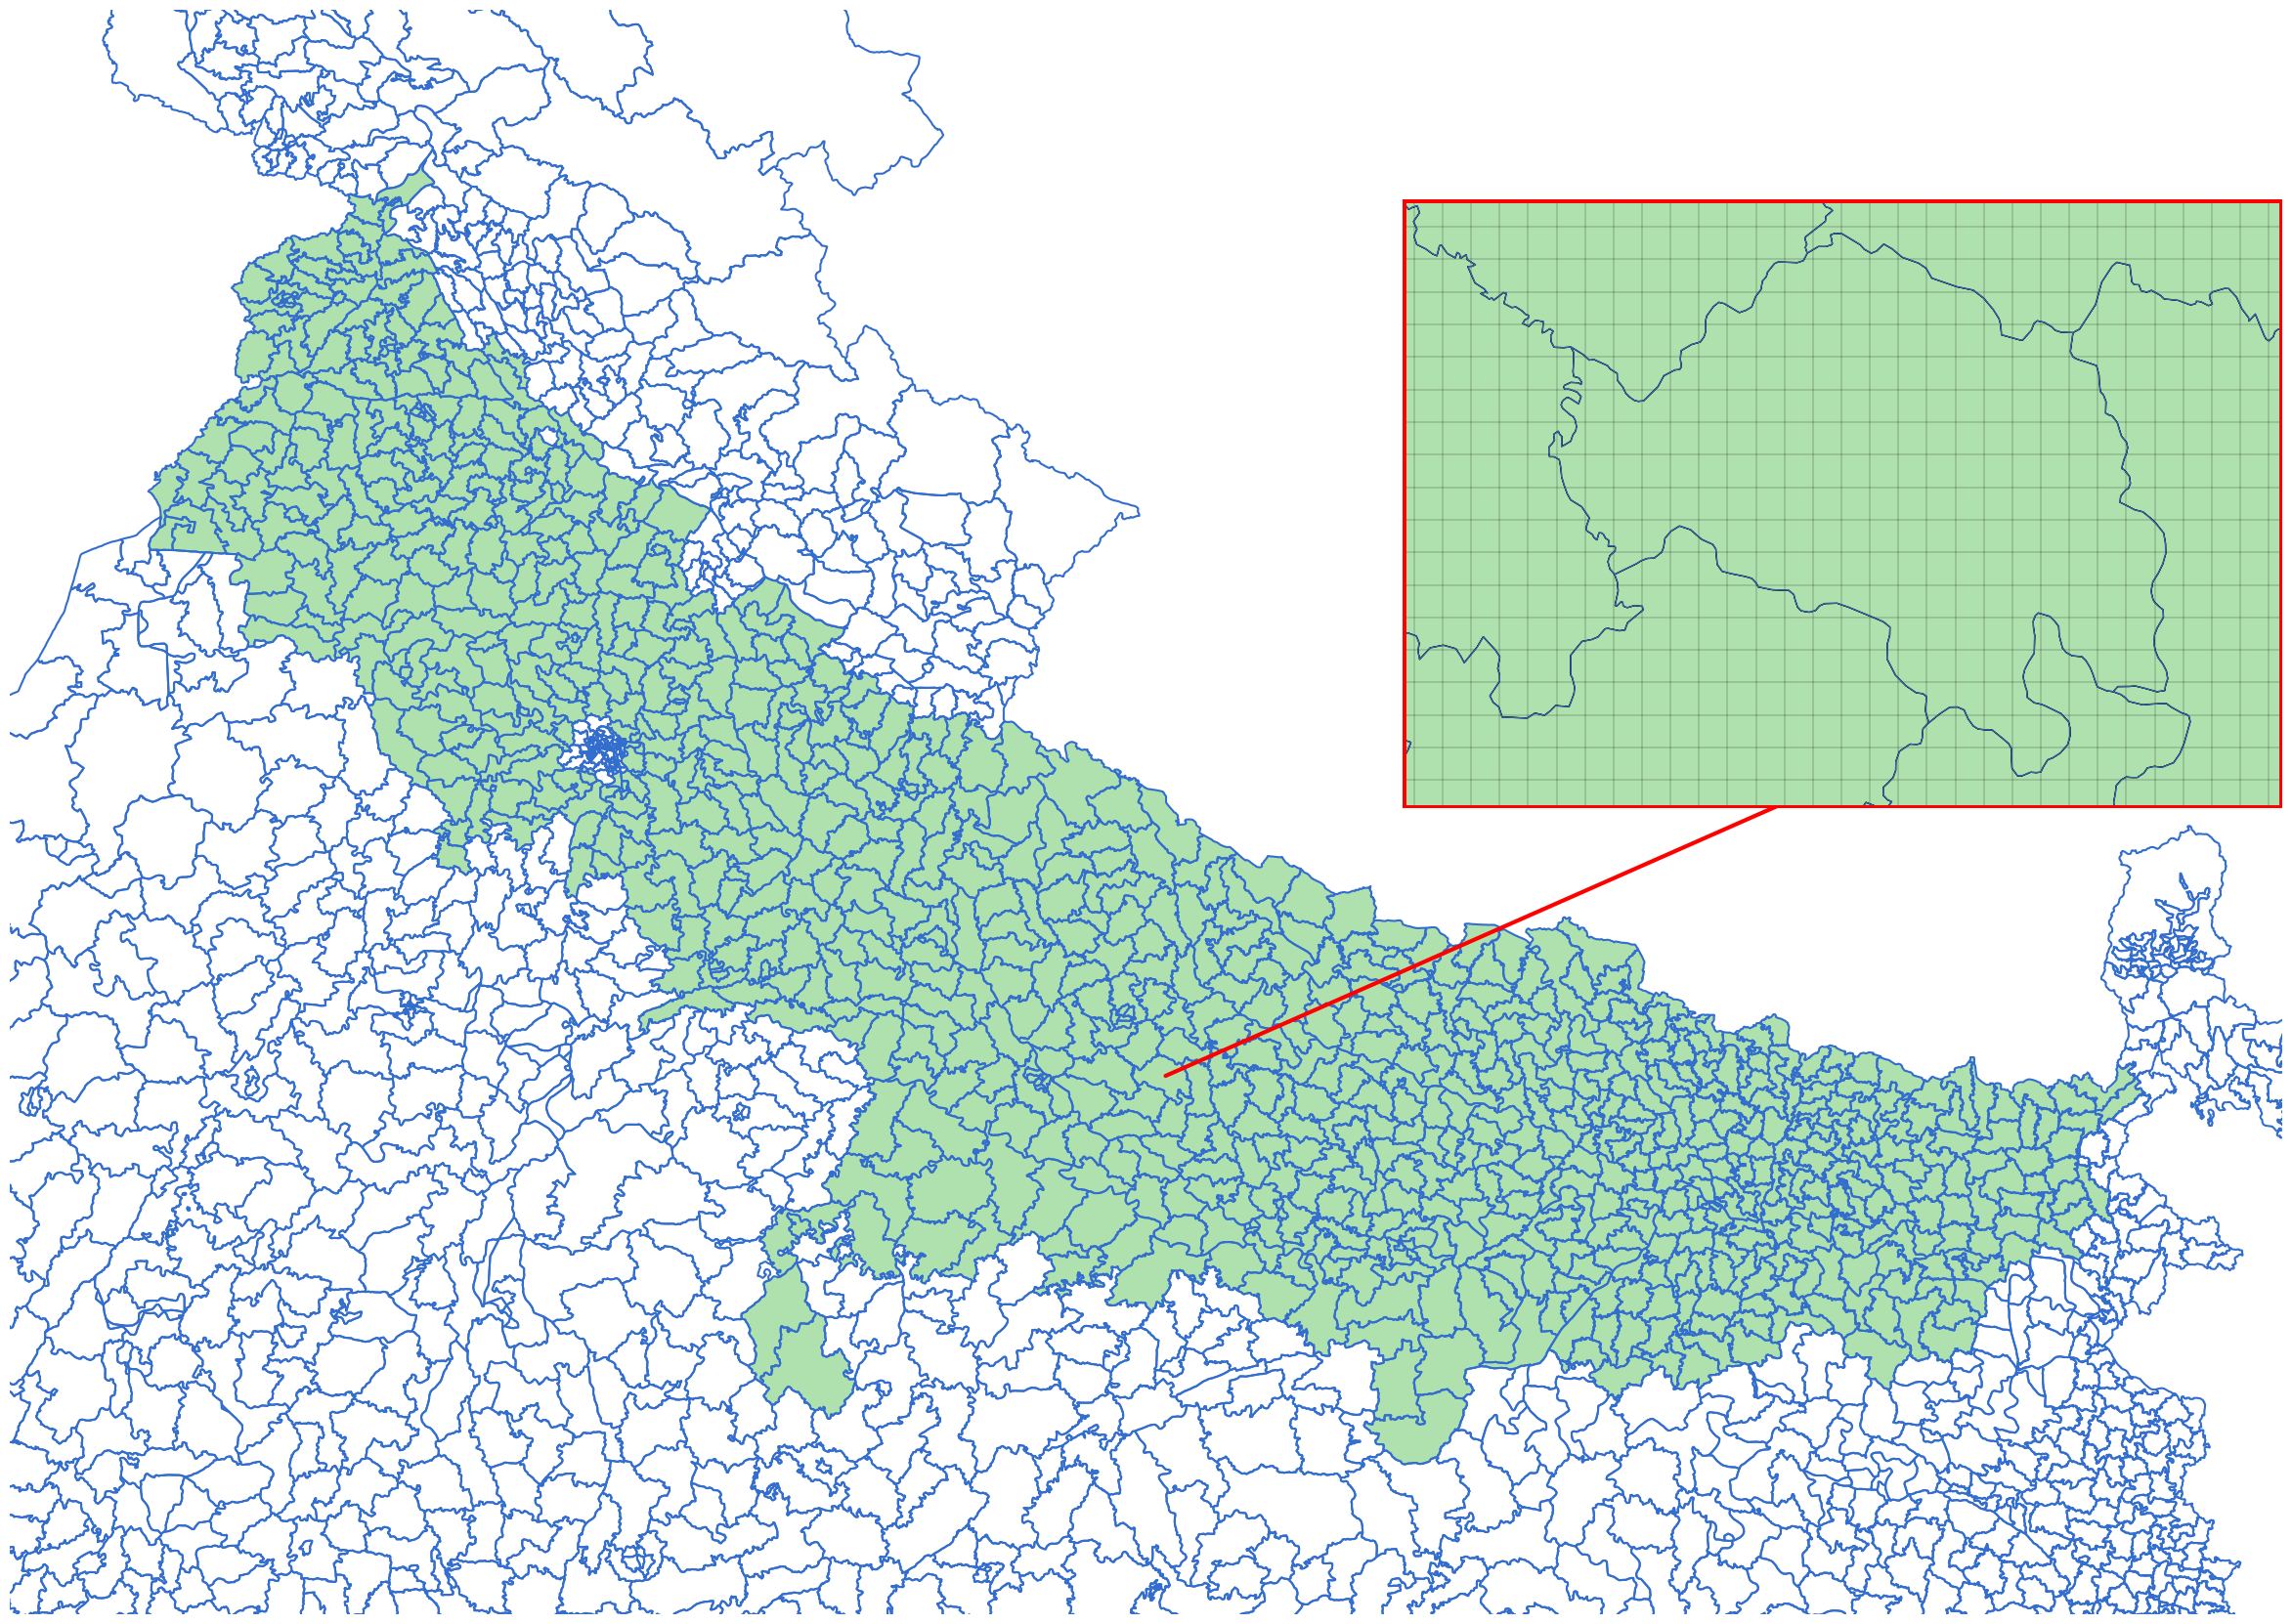

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.patches import FancyArrowPatch

# Assuming sel_states_shp and polygons are already loaded
# Select the district with dist_id == 156
selected_acs = acs.query('ac_uq_id == 780').copy()

# Calculate the total bounds of sel_states_shp and add a margin
xmin, ymin, xmax, ymax = sel_states_shp.total_bounds
x_margin = 1.0  # 1 degree added to each side
y_margin = 1.0

# Set up the main plot
fig, ax = plt.subplots(figsize=(30, 30))

# Plot sel_states_shp with green fill and no edge
sel_states_shp.plot(ax=ax, color='#AFE1AF', edgecolor=None)

# Plot polygons with only boundaries in blue
polygons.boundary.plot(ax=ax, color='#336ece')

# Set the axis limits with added margins
ax.set_xlim(xmin - x_margin, xmax + x_margin)
ax.set_ylim(ymin - y_margin, ymax + y_margin)

# Add other plot customizations if needed
ax.axis('off')  # Turn off the axis

# Create an inset axis for the zoomed-in district
inset_ax = fig.add_axes([0.6, 0.45, 0.3, 0.3])  # [left, bottom, width, height] in figure coordinates

# Plot the selected district in the inset
polygons.plot(ax=inset_ax, color='#AFE1AF', edgecolor='black')

# Optionally, plot the surrounding polygons with boundaries in the inset (if needed)
polygons.boundary.plot(ax=inset_ax, color='#336ece', linewidth=0.5)

# adding the grid
grid.plot(ax=inset_ax, facecolor='none', edgecolor='black', linewidth=0.1)

# Set limits for the inset axis based on the bounds of the selected district with a margin
xmin_inset, ymin_inset, xmax_inset, ymax_inset = selected_acs.total_bounds
x_inset_margin = 0.1  # Adjust margin as needed for better visibility
y_inset_margin = 0.02

inset_ax.set_xlim(xmin_inset - x_inset_margin, xmax_inset + x_inset_margin)
inset_ax.set_ylim(ymin_inset - y_inset_margin, ymax_inset + y_inset_margin)

# Hide axis for the inset plot
inset_ax.axis('off')

# Add a red square around the inset plot
rect = Rectangle((0, 0), 1, 1, transform=inset_ax.transAxes,
                 color='red', fill=False, lw=5, zorder=9)
inset_ax.add_patch(rect)

# Calculate the centroid of the selected district
centroid = selected_acs.geometry.centroid.iloc[0]



# Add an arrow from the centroid to the midpoint of the inset's bottom line
arrow = FancyArrowPatch((centroid.x, centroid.y), (centroid.x + 5.4, centroid.y + 2.2),
                        transform=ax.transData,
                        color='red', arrowstyle='->', lw=3, zorder=10)
ax.add_patch(arrow)

# Save the code
fig.savefig( f"../tex/paper/figures/map_grids.pdf", 
            format='pdf', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [ ]:
# Save the code
fig.savefig( f"../tex/paper/figures/map_grids.png", dpi=300, bbox_inches='tight')

In [ ]:
### Plot of witchers politician charactersitics

In [3]:
dbox_root = 'C:/Users/rjbar/Saadgulzar Dropbox/rbarreraf@fen.uchile.cl/sa_fires'
shell_root = '/groups/sgulzar/sa_fires'
root = dbox_root
int_farms = f"{root}/proj_bureaucrats_farms/data_output/intermediate"
table_farms = f"{root}/proj_bureaucrats_farms/tex/paper/tables"
figure_farms = f"{root}/proj_bureaucrats_farms/tex/paper/figures"


In [8]:
import polars as pl
file_path = fr"{int_farms}/0_master_merge_data_gen.csv"
df = pl.read_csv(file_path, columns=["ac_uq_id", "self_profession"], ignore_errors = True)


In [4]:
df = pd.read_csv(r'C:\Users\rjbar\Documents\sa_fires\cohortes_prof_anyst\politicians_characteristics.csv')

In [6]:
df = df[['cohort', 'ac_uq_id','self_prof','election_year']].drop_duplicates()

In [7]:
switchers = df[df['self_prof'] == 1].drop_duplicates()
switchers['num_elections'] = switchers.groupby('ac_uq_id')['election_year'].transform('nunique')
switchers = switchers[['ac_uq_id','num_elections']].drop_duplicates()

df = df.merge(switchers, on='ac_uq_id', how='left')
df['num_elections'] = df['num_elections'].fillna(0)

In [8]:
gdf = acs.merge(df, how='left', on='ac_uq_id')

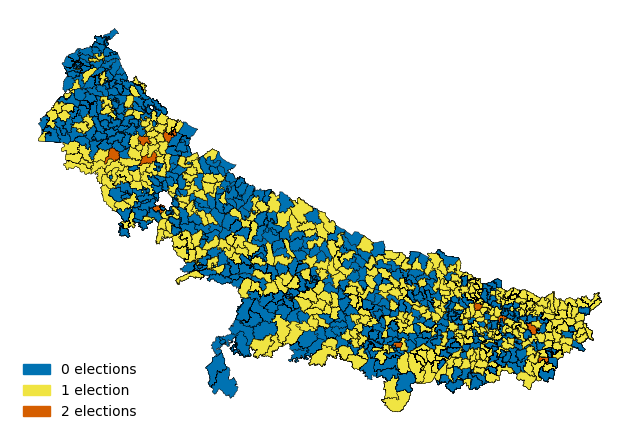

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define colors: 0=control, 1=switchers, 2=treated
color_map = {
    0: "#0072B2",  # non-switcher control (blue)
    1: "#F0E442",  # switchers (yellow)
    2: "#D55E00"   # non-switcher treated (orange)
}

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(
    ax=ax,
    color=gdf["num_elections"].fillna(0).map(color_map),
    edgecolor="black",
    linewidth=0.3
)

# Manually create legend patches
legend_labels = {
    0: "0 elections",
    1: "1 election",
    2: "2 elections"
}
patches = [
    mpatches.Patch(color=color_map[val], label=label)
    for val, label in legend_labels.items()
]

# Add legend
ax.legend(handles=patches, title="", loc="lower left", frameon = False)

# Remove axis ticks/labels
ax.set_axis_off()

plt.axis("off")

#plt.savefig(r"../tex/paper/figures/8_polisc_switchers.png", dpi=300, bbox_inches="tight", transparent=True)

plt.show()

In [14]:
import pandas as pd

# Group and compute min/max
agg_df = (
    df.groupby("ac_uq_id", as_index=False)
    .agg(
        min_prof=("self_profession", "min"),
        max_prof=("self_profession", "max")
    )
)

# Define switcher categories
def classify(row):
    if row["min_prof"] == 0 and row["max_prof"] == 0:
        return 0   # never treated (stayers)
    elif row["min_prof"] == 1 and row["max_prof"] == 1:
        return 2   # always treated
    else:
        return 1   # switchers

agg_df["switcher"] = agg_df.apply(classify, axis=1)

print(agg_df)


AttributeError: 'DataFrame' object has no attribute 'groupby'

In [3]:
import geopandas as gpd

In [4]:
acs = gpd.read_file('../data_output/intermediate/_0_2_3_ACs_right_shapefile.shp')

In [16]:
gdf = acs.merge(agg_df)

NameError: name 'agg_df' is not defined

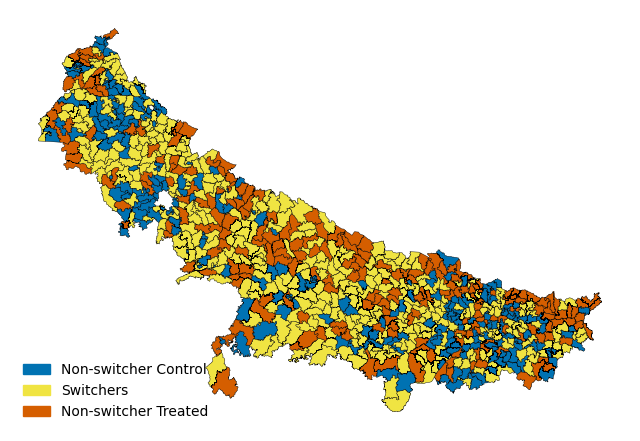

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define colors: 0=control, 1=switchers, 2=treated
color_map = {
    0: "#0072B2",  # non-switcher control (blue)
    1: "#F0E442",  # switchers (yellow)
    2: "#D55E00"   # non-switcher treated (orange)
}

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(
    ax=ax,
    color=gdf["switcher"].map(color_map),
    edgecolor="black",
    linewidth=0.3
)

# Manually create legend patches
legend_labels = {
    0: "Non-switcher Control",
    1: "Switchers",
    2: "Non-switcher Treated"
}
patches = [
    mpatches.Patch(color=color_map[val], label=label)
    for val, label in legend_labels.items()
]

# Add legend
ax.legend(handles=patches, title="", loc="lower left", frameon = False)

# Remove axis ticks/labels
ax.set_axis_off()

plt.axis("off")

plt.savefig(
    r"../tex/paper/figures/8_polisc_switchers.png",
    dpi=300,          # high resolution
    bbox_inches="tight",  # trims extra white margins
    transparent=True      # no white background
)


plt.show()


In [14]:
### Downup swtichers

In [17]:
import polars as pl
file_path = fr"{int_farms}/0_master_merge_data_gen.csv"
df = pl.read_csv(file_path, columns=["unique_small_grid_id", "year", "month", "downup_ac"], 
                 ignore_errors = True).to_pandas()


In [ ]:
# Ensure correct ordering by id, year, month
df = df.sort_values(["unique_small_grid_id", "year", "month"])

# Create lag column
df["downup_ac_lag"] = (
    df.groupby("unique_small_grid_id")["downup_ac"]
      .shift(1)   # lag of 1 period
)



     year  month  unique_small_grid_id  downup_ac  downup_ac_lag
147  2012      9                    23          1            NaN
146  2012     10                    23          1            1.0
145  2012     11                    23          1            1.0
144  2012     12                    23          1            1.0
143  2013      1                    23          1            1.0


In [21]:
nov14 = df.query('year == 2014 & month ==11')


In [22]:
def classify(row):
    if row["downup_ac_lag"] == 0 and row["downup_ac"] == 0:
        return 0   # never treated (stayers)
    elif row["downup_ac_lag"] == 1 and row["downup_ac"] == 1:
        return 2   # always treated
    else:
        return 1   # switchers

nov14["switcher"] = nov14.apply(classify, axis=1)


C:\Users\Anzony\AppData\Local\Temp\ipykernel_10940\1678888305.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nov14["switcher"] = nov14.apply(classify, axis=1)


In [25]:
grid = gpd.read_file( f"../../proj_downwind/data_output/intermediate/1-grid-generation.shp" )

In [27]:
grid.columns = ['id', 'split_d', 'split', 'unique_small_grid_id', 'geometry']

In [28]:
nov14_shp = grid.merge(nov14)

In [31]:
nov14_shp.switcher.value_counts()

switcher
2    47047
0    46025
1     7182
Name: count, dtype: int64

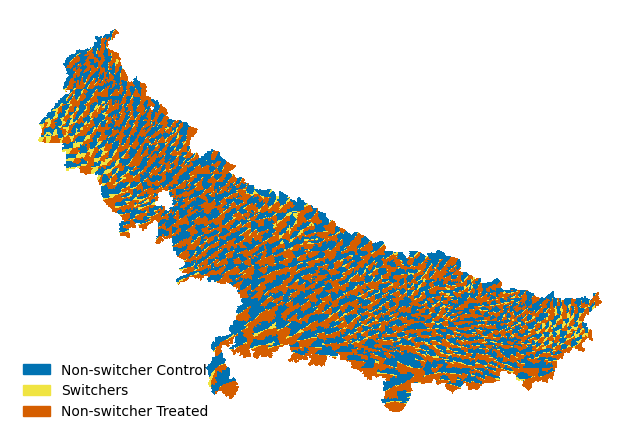

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define colors: 0=control, 1=switchers, 2=treated
color_map = {
    0: "#0072B2",  # non-switcher control (blue)
    1: "#F0E442",  # switchers (yellow)
    2: "#D55E00"   # non-switcher treated (orange)
}

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
nov14_shp.plot(
    ax=ax,
    color=nov14_shp["switcher"].map(color_map),
    edgecolor="none", linewidth=0,  antialiased=False
)

# Manually create legend patches
legend_labels = {
    0: "Non-switcher Control",
    1: "Switchers",
    2: "Non-switcher Treated"
}
patches = [
    mpatches.Patch(color=color_map[val], label=label)
    for val, label in legend_labels.items()
]

# Add legend
ax.legend(handles=patches, title="", loc="lower left", frameon = False)

plt.savefig(
    r"../tex/paper/figures/downup_switchers.png",
    dpi=300,          # high resolution
    bbox_inches="tight",  # trims extra white margins
    transparent=True      # no white background
)

plt.axis("off")
plt.show()

### Neighbor Plot

In [7]:
import polars as pl

In [8]:
# Selecting polygon
ac_sel = 780
sel_polygon = acs.query(f'ac_uq_id == {ac_sel}').copy()

In [9]:
df = pl.read_csv("../data_output/intermediate/10_ac_neighs_downup.csv")
df_filtered = df.filter(pl.col("ac_uq_id") == ac_sel)
df_pd = df_filtered.to_pandas()

neighs = df_pd['ac_uq_id_neighbor'].unique().tolist()
neighs_sel = acs.query(f'ac_uq_id.isin({neighs})').copy()

In [11]:
grids_sel = df_pd['unique_small_grid_id'].unique().tolist()
selected_grids = grid.query(f'unq_s__.isin({grids_sel})').copy()
selected_grids.columns = ['id', 'split_d', 'split', 'unique_small_grid_id', 'geometry']

In [12]:
neigh_dist = df_pd.query('ac_uq_id_neighbor==516')[['unique_small_grid_id', 'dist_q']]
selgrids_distance = selected_grids.merge(neigh_dist )

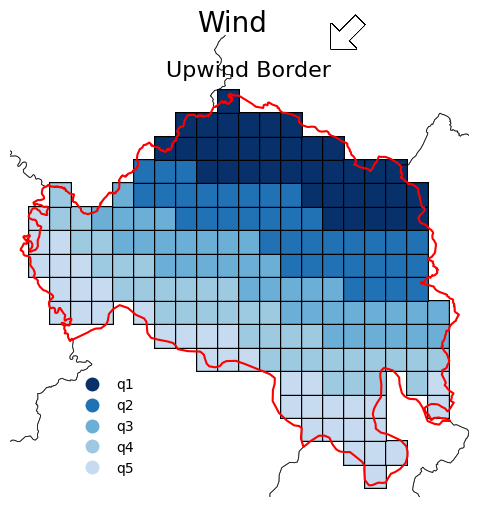

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

# Define categorical labels
labels = ["q1", "q2", "q3", "q4", "q5"]

# Blue shades from dark to light (no white)
colors = ["#08306b", "#2171b5", "#6baed6", "#9ecae1", "#c6dbef"]
cmap = mcolors.ListedColormap(colors)

# Ensure dist_q is categorical
selgrids_distance["dist_q"] = selgrids_distance["dist_q"].astype(int)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

# Grid polygons
selgrids_distance.plot(
    ax=ax,
    column="dist_q",
    cmap=cmap,
    legend=True,
    linewidth=0.3,
    edgecolor="black",   # show grid lines
    categorical=True
)

# Legend tweaks
leg = ax.get_legend()
for t, label in zip(leg.texts, labels):
    t.set_text(label)

leg.set_title("")
leg.set_frame_on(False)   
leg.set_bbox_to_anchor((0.12, 0.02))  
leg._loc = 3  

# Plot neighbors and selection polygon
neighs_sel.boundary.plot(ax=ax, color="black", linewidth=0.6, alpha=0.7)
sel_polygon.boundary.plot(ax=ax, color="red", linewidth=1.5)

# Zoom into buffered bounding box
minx, miny, maxx, maxy = sel_polygon.total_bounds
buffer = 0.01
ax.set_xlim(minx - buffer, maxx + buffer)
ax.set_ylim(miny - buffer, maxy + 5*buffer)

# ---- Add PNG arrow at the top center ----
arrow_img = mpimg.imread(r"../tex\paper\figures\row_fromtop2bott45.png")

# Convert to an OffsetImage (adjust zoom to control size)
imagebox = OffsetImage(arrow_img, zoom=0.04)  

# Place it in the middle top
arrow_x = (maxx+minx )/2 + 0.1
arrow_y = maxy + 5*buffer
ab = AnnotationBbox(
    imagebox, 
    (arrow_x, arrow_y),  
    frameon=False
)
ax.add_artist(ab)

# ---- Add text "Wind" next to the arrow ----
ax.text(
    81.15, arrow_y+0.01,   # shift a bit right of the arrow
    "Wind",
    fontsize=20, ha="left", va="center"
)


ax.text(
    (maxx+minx )/2 -0.07, maxy + 2*buffer,   # shift a bit right of the arrow
    "Upwind Border",
    fontsize=16, ha="left", va="center"
)


# Remove axis ticks/labels
ax.set_axis_off()

plt.savefig(
    r"../tex/paper/figures/wind_neigh_dir_top2bott.png",
    dpi=300,          # high resolution
    bbox_inches="tight",  # trims extra white margins
    transparent=True      # no white background
)

plt.show()


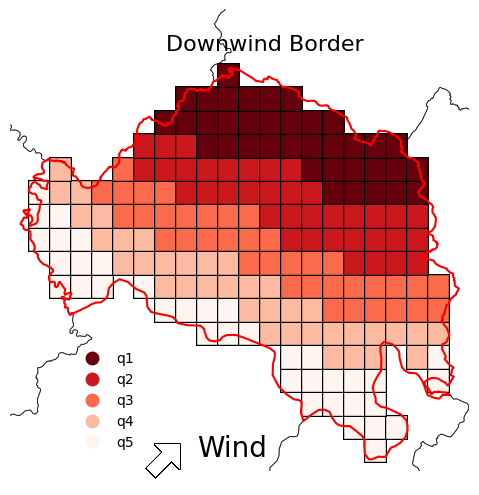

In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

# Define categorical labels
labels = ["q1", "q2", "q3", "q4", "q5"]

# Blue shades from dark to light (no white)
colors = [ "#67000d",  "#cb181d","#fb6a4a", "#fcbba1","#fff5f0", ]

cmap = mcolors.ListedColormap(colors)

# Ensure dist_q is categorical
selgrids_distance["dist_q"] = selgrids_distance["dist_q"].astype(int)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

# Grid polygons
selgrids_distance.plot(
    ax=ax,
    column="dist_q",
    cmap=cmap,
    legend=True,
    linewidth=0.3,
    edgecolor="black",   # show grid lines
    categorical=True
)

# Legend tweaks
leg = ax.get_legend()
for t, label in zip(leg.texts, labels):
    t.set_text(label)

leg.set_title("")
leg.set_frame_on(False)   
leg.set_bbox_to_anchor((0.12, 0.02))  
leg._loc = 3  

# Plot neighbors and selection polygon
neighs_sel.boundary.plot(ax=ax, color="black", linewidth=0.6, alpha=0.7)
sel_polygon.boundary.plot(ax=ax, color="red", linewidth=1.5)

# Zoom into buffered bounding box
minx, miny, maxx, maxy = sel_polygon.total_bounds
buffer = 0.01
ax.set_xlim(minx - buffer, maxx + buffer)
ax.set_ylim(miny - buffer, maxy + 5*buffer)

# ---- Add PNG arrow at the top center ----
arrow_img = mpimg.imread(r"../tex\paper\figures\row_from_bott2top45.png")

# Convert to an OffsetImage (adjust zoom to control size)
imagebox = OffsetImage(arrow_img, zoom=0.04)  

# Place it in the middle top
arrow_x = 81.12
arrow_y = miny
ab = AnnotationBbox(
    imagebox, 
    (arrow_x, arrow_y),  
    frameon=False
)
ax.add_artist(ab)

# ---- Add text "Wind" next to the arrow ----
ax.text(
    81.15, arrow_y+0.01,   # shift a bit right of the arrow
    "Wind",
    fontsize=20, ha="left", va="center"
)


ax.text(
    (maxx+minx )/2 -0.07, maxy + 2*buffer,   # shift a bit right of the arrow
    "Downwind Border",
    fontsize=16, ha="left", va="center"
)


# Remove axis ticks/labels
ax.set_axis_off()

plt.savefig(
    r"../tex/paper/figures/wind_neigh_dir_bott2top.png",
    dpi=300,          # high resolution
    bbox_inches="tight",  # trims extra white margins
    transparent=True      # no white background
)

plt.show()


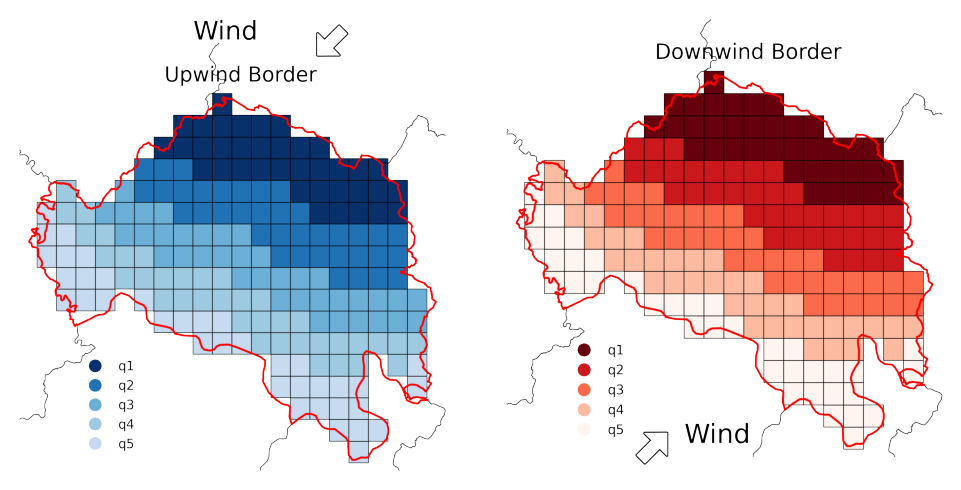

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# File paths
img1_path = r"../tex/paper/figures/wind_neigh_dir_top2bott.png"
img2_path = r"../tex/paper/figures/wind_neigh_dir_bott2top.png"

# Load images
img1 = mpimg.imread(img1_path)
img2 = mpimg.imread(img2_path)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img1)
axes[0].axis("off")
# axes[0].set_title("Top → Bottom")

axes[1].imshow(img2)
axes[1].axis("off")
# axes[1].set_title("Bottom → Top")

# Save the combined figure
out_path = r"../tex/paper/figures/neighbor_test_explained_ac.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()


In [75]:
(minx + maxx) / 2

np.float64(81.19068065119214)

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.offsetbox as offsetbox
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import FancyArrowPatch
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from scipy.spatial import Voronoi, voronoi_plot_2d
import numpy as np
from shapely.geometry import LineString
from shapely.geometry import LineString, Point


In [10]:
ac_sel = 780

In [8]:
acs['area_latlon'] = acs.area.copy()

C:\Users\187697\AppData\Local\Temp\ipykernel_9960\2081343593.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  acs['area_latlon'] = acs.area.copy()


In [42]:
acs.query(f'area_latlon < 0.033877').sort_values('area_latlon', ascending = False )

,ac_uq_id,STATE_UT,DISTRICT,ASSEMBLY_1,ASSEMBLY,acpost08ID,geometry,area_latlon
822,61,BIHAR,GAYA,WAZIRGANJ,234.0,505.0,"POLYGON ((85.30412 24.82649, 85.30424 24.82627...",0.033808
670,211,BIHAR,SHEIKHPURA,SHEIKHPURA,169.0,643.0,"MULTIPOLYGON (((85.83515 25.22039, 85.83609 25...",0.033761
478,28,BIHAR,BHAGALPUR,NATHNAGAR,157.0,651.0,"POLYGON ((86.91187 25.09695, 86.90732 25.09878...",0.033546
582,172,BIHAR,PURVI CHAMPARAN,KESARIA,15.0,594.0,"POLYGON ((84.7127 26.50981, 84.7127 26.50981, ...",0.033541
357,141,BIHAR,PASCHIM CHAMPARAN,NARKATIAGANJ,3.0,610.0,"POLYGON ((84.5325 27.03923, 84.53106 27.03483,...",0.033380
...,...,...,...,...,...,...,...,...
66,670,UTTAR PRADESH,KANPUR NAGAR,ARYA NAGAR,214.0,3486.0,"POLYGON ((80.37962 26.46282, 80.38064 26.4613,...",0.001048
791,403,PUNJAB,LUDHIANA,LUDHIANA CENTRAL,63.0,3047.0,"POLYGON ((75.89534 30.90046, 75.89661 30.89873...",0.000959
182,679,UTTAR PRADESH,KANPUR NAGAR,SISHAMAU,213.0,3457.0,"POLYGON ((80.34033 26.42437, 80.33925 26.43147...",0.000744
407,334,PUNJAB,AMRITSAR,AMRITSAR CENTRAL,17.0,3100.0,"POLYGON ((74.86728 31.61607, 74.86379 31.61835...",0.000729


In [43]:
ac_sel = 61

In [44]:
# Selecting polygon
sel_polygon = acs.query(f'ac_uq_id == {ac_sel}').copy()

In [52]:
sel_polygon

,ac_uq_id,STATE_UT,DISTRICT,ASSEMBLY_1,ASSEMBLY,acpost08ID,geometry,area_latlon
822,61,BIHAR,GAYA,WAZIRGANJ,234.0,505.0,"POLYGON ((85.30412 24.82649, 85.30424 24.82627...",0.033808


In [ ]:
import polars as pl

# 1. Load the data
file_path = r"..\data_output\intermediate\0_master_merge_data_gen.csv"
df = pl.read_csv(file_path, ignore_errors=True)


In [45]:

# 2. Filter
df_filtered = df.filter(
    (pl.col("ac_uq_id") == ac_sel) &
    (pl.col("month") == 12) &
    (pl.col("year") == 2020)
)

# 3. Select only the column and convert to pandas
grids_832 = df_filtered.select("unique_small_grid_id").to_pandas()

In [46]:
grid = grid.rename(columns ={'unq_s__' : 'unique_small_grid_id'})

In [47]:
sel_grids = gpd.GeoDataFrame(grids_832.merge(grid, on = 'unique_small_grid_id'))

C:\Users\187697\AppData\Local\Temp\ipykernel_9960\3531651182.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  acs_up["centroid"] = acs_up.geometry.centroid


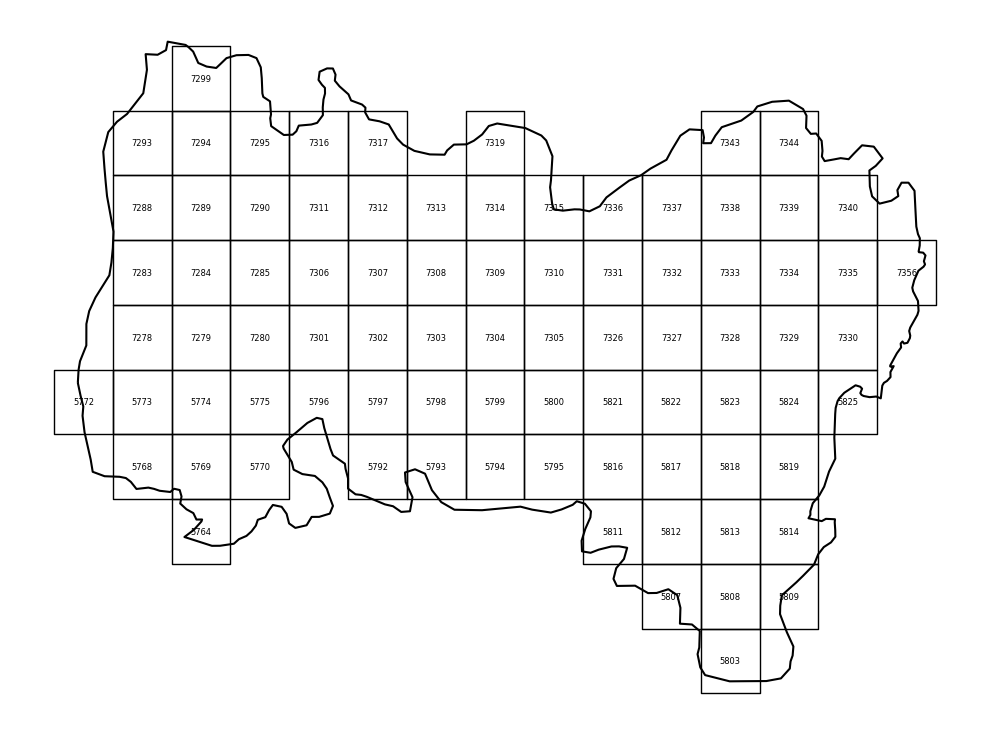

In [48]:
acs_up = sel_grids.copy()

acs_up["centroid"] = acs_up.geometry.centroid

# Plot polygons
fig, ax = plt.subplots(figsize=(10, 8))
acs_up.plot(ax=ax, edgecolor='black', facecolor='none')
sel_polygon.boundary.plot(ax=ax, edgecolor='black')
# Add labels at centroids
for idx, row in acs_up.iterrows():
    ax.annotate(
        text=row["unique_small_grid_id"],
        xy=(row["centroid"].x, row["centroid"].y),
        ha="center", va="center",
        fontsize=6
    )

ax.set_axis_off()
plt.tight_layout()

# Save as PNG
# plt.savefig("../tex/paper/figures/acs_grids.png", dpi=300, bbox_inches="tight")

plt.show()

C:\Users\187697\AppData\Local\Temp\ipykernel_9960\291390671.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = row.geometry.centroid.to_crs(7755)  # in meters


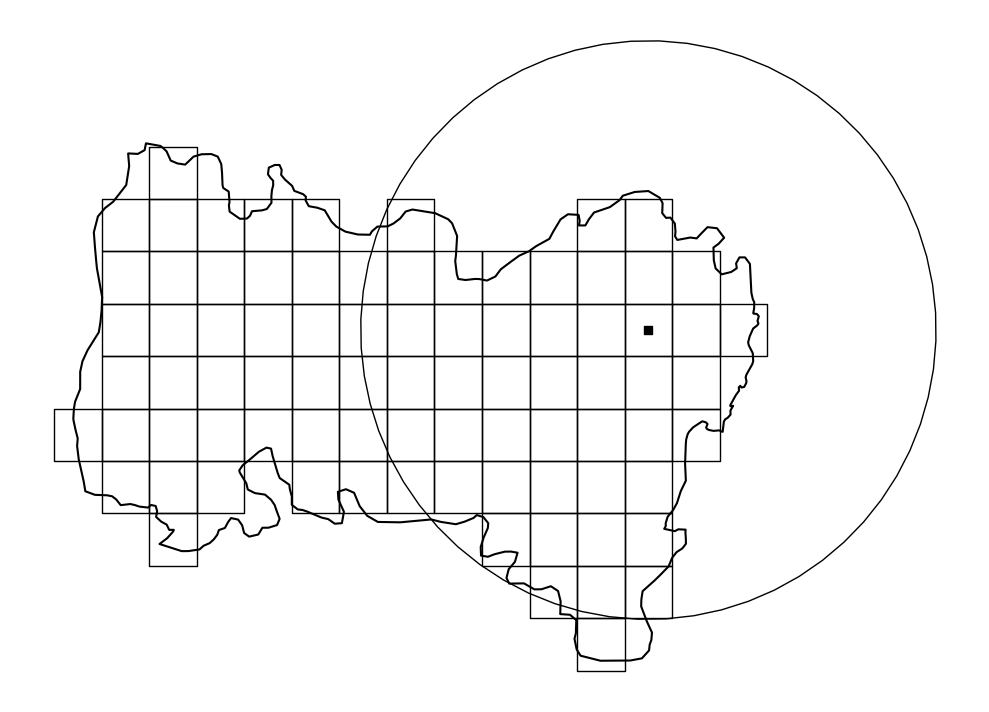

In [51]:
import matplotlib.pyplot as plt

# Select the row with unique_small_grid_id == 42236
row = acs_up[acs_up["unique_small_grid_id"] == 7334].iloc[[0], :].copy()

# Get centroid and buffer 12 km (12000 meters)
centroid = row.geometry.centroid.to_crs(7755)  # in meters
geo = centroid.buffer(12000).to_crs(4326)

row = row.drop('centroid', axis=1, errors="ignore")
row['geometry'] = geo
row = gpd.GeoDataFrame(row, crs=4326)

# Plot polygons
fig, ax = plt.subplots(figsize=(10, 8))
acs_up.plot(ax=ax, edgecolor='black', facecolor='none')
sel_polygon.boundary.plot(ax=ax, edgecolor='black')

# Plot buffer border only
row.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

# Plot centroid as a square marker
centroid.to_crs(4326).plot(ax=ax, color="black", marker="s", markersize=40)

ax.set_axis_off()
plt.tight_layout()

# Save as PNG
plt.savefig("../tex/paper/figures/acs_grids_radius12km.png", dpi=300, bbox_inches="tight")
plt.show()


In [28]:
# Load the fire icon
fire_icon = mpimg.imread('../../proj_downwind/tex/paper/figures/fire.png')


C:\Users\rjbar\AppData\Local\Temp\ipykernel_27132\311595169.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  selected_centroid = selected_cell.geometry.centroid.iloc[0]


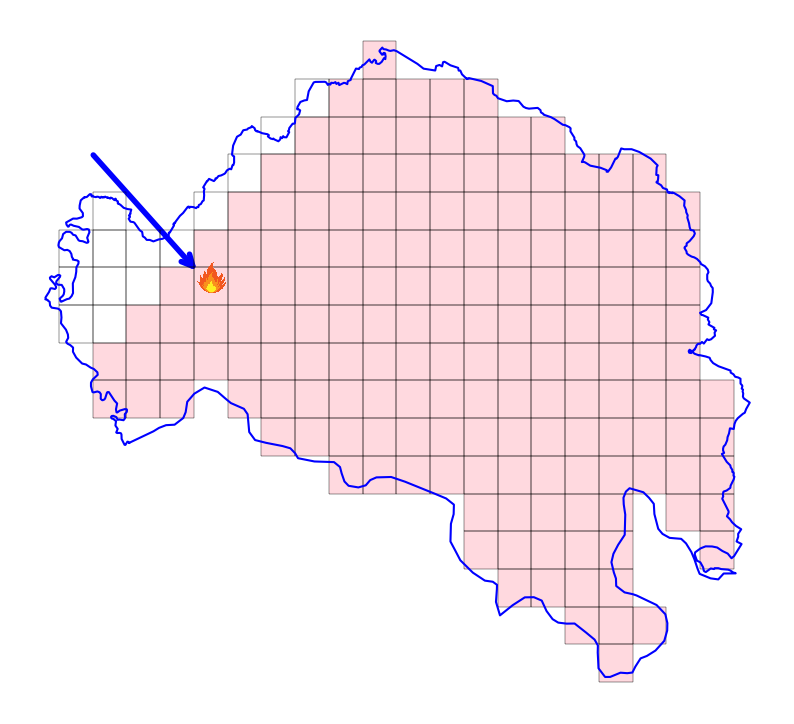

In [39]:
# Select the cell with ID == 1270
selected_cell = sel_grids[sel_grids['unique_small_grid_id'] == 42175]

# Extract its centroid
selected_centroid = selected_cell.geometry.centroid.iloc[0]


# Generate a sufficiently long line with 45-degree inclination
length = max(sel_polygon.total_bounds[2] - sel_polygon.total_bounds[0], sel_polygon.total_bounds[3] - sel_polygon.total_bounds[1]) * 2

# Calculate end points for the line
start_point = (selected_centroid.x - length / 2, selected_centroid.y - length / 2)
end_point = (selected_centroid.x + length / 2, selected_centroid.y + length / 2)

# Create the line
line = LineString([start_point, end_point])


# Create a function to determine if a polygon is below the line
def is_below_line(polygon, line):
    # Check if all points in the polygon are below the line
    coords = polygon.exterior.coords
    for coord in coords:
        if line.xy[1][1] > line.xy[1][0]:  # Positive slope
            if coord[1] > (line.xy[1][1] - line.xy[1][0]) / (line.xy[0][1] - line.xy[0][0]) * (coord[0] - line.xy[0][0]) + line.xy[1][0]:
                return False
        else:  # Negative slope
            if coord[1] < (line.xy[1][1] - line.xy[1][0]) / (line.xy[0][1] - line.xy[0][0]) * (coord[0] - line.xy[0][0]) + line.xy[1][0]:
                return False
    return True

# Determine which Voronoi cells are below the line
sel_grids['below_line'] = sel_grids.geometry.apply(lambda x: is_below_line(x, line))

# Function to determine if a polygon is below or touches the line
def is_below_or_touches_line(polygon, line):
    # Check if the polygon intersects the line or if all points of the polygon are below the line
    if polygon.intersects(line):
        return True
    else:
        # Convert the line into a function and check if all points are below the line
        for x, y in polygon.exterior.coords:
            point = Point(x, y)
            projected_point = line.interpolate(line.project(point))
            if y >= projected_point.y:
                return False
        return True


# Determine which Voronoi cells are below the line or touch it
sel_grids['below_or_touches_line'] = sel_grids.geometry.apply(lambda x: is_below_or_touches_line(x, line))


# Calculate the vector perpendicular to the line
line_vector = np.array([end_point[0] - start_point[0], end_point[1] - start_point[1]])
perpendicular_vector = np.array([-line_vector[1], line_vector[0]])
perpendicular_vector = perpendicular_vector / np.linalg.norm(perpendicular_vector)  # Normalize the vector

# Calculate the arrow's start and end points
arrow_start = np.array([selected_centroid.x, selected_centroid.y]) + perpendicular_vector * 0.1  # Adjust scale
arrow_end = np.array([selected_centroid.x, selected_centroid.y]) - perpendicular_vector * (-0.01)  # Adjust scale

# Create the main plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot all Voronoi cells (this will be under the selected cell)
sel_grids.boundary.plot(ax=ax, color='black', linewidth=0.3)

# Fill the cells below or touching the line with pink color and alpha = 0.6
sel_grids[sel_grids['below_or_touches_line']].plot(ax=ax, color='pink', alpha=0.6, antialiased=False)

# Plot the polygon boundary
sel_polygon.boundary.plot(ax=ax, color='blue', linewidth=1.5)



# Insert the fire icon as an annotation with an OffsetImage
imagebox = offsetbox.OffsetImage(fire_icon, zoom=0.015)  # Adjust zoom for icon size
ab = offsetbox.AnnotationBbox(imagebox, (selected_centroid.x, selected_centroid.y + 0.005 ),
                              frameon=False, boxcoords="data", pad=0)
ax.add_artist(ab)


# Add an arrow pointing to the selected cell
arrow = FancyArrowPatch(posA=arrow_start, posB=arrow_end, arrowstyle='->',
                        color='blue', mutation_scale=20, lw=4)
ax.add_patch(arrow)

# Set title and remove axes for the main plot
# ax.set_title('Voronoi Cells Below or Touching the 45-degree Line with Fire Icon')
ax.set_axis_off()

# Save the figure as a PNG file
plt.savefig( f'../tex/paper/figures/downwind_ac.png',
            format = 'png', dpi=300, bbox_inches='tight')

plt.show()

In [41]:
sel_grids.query('unique_small_grid_id==42232')

,unique_small_grid_id,id,split_d,split,geometry,below_line,below_or_touches_line
105,42232,69211,7,1.0,"POLYGON ((81.31 26.41, 81.31 26.43, 81.33 26.4...",True,True


C:\Users\rjbar\AppData\Local\Temp\ipykernel_27132\1933666128.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  selected_centroid = selected_cell.geometry.centroid.iloc[0]


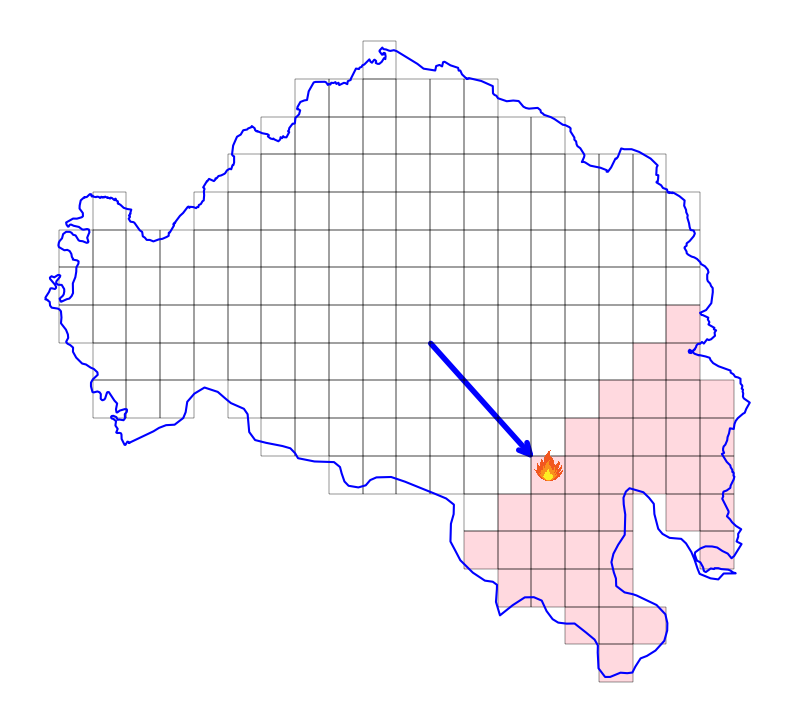

In [49]:
# Select the cell with ID == 1270
selected_cell = sel_grids[sel_grids['unique_small_grid_id'] == 39875]

# Extract its centroid
selected_centroid = selected_cell.geometry.centroid.iloc[0]


# Generate a sufficiently long line with 45-degree inclination
length = max(sel_polygon.total_bounds[2] - sel_polygon.total_bounds[0], sel_polygon.total_bounds[3] - sel_polygon.total_bounds[1]) * 2

# Calculate end points for the line
start_point = (selected_centroid.x - length / 2, selected_centroid.y - length / 2)
end_point = (selected_centroid.x + length / 2, selected_centroid.y + length / 2)

# Create the line
line = LineString([start_point, end_point])


# Create a function to determine if a polygon is below the line
def is_below_line(polygon, line):
    # Check if all points in the polygon are below the line
    coords = polygon.exterior.coords
    for coord in coords:
        if line.xy[1][1] > line.xy[1][0]:  # Positive slope
            if coord[1] > (line.xy[1][1] - line.xy[1][0]) / (line.xy[0][1] - line.xy[0][0]) * (coord[0] - line.xy[0][0]) + line.xy[1][0]:
                return False
        else:  # Negative slope
            if coord[1] < (line.xy[1][1] - line.xy[1][0]) / (line.xy[0][1] - line.xy[0][0]) * (coord[0] - line.xy[0][0]) + line.xy[1][0]:
                return False
    return True

# Determine which Voronoi cells are below the line
sel_grids['below_line'] = sel_grids.geometry.apply(lambda x: is_below_line(x, line))

# Function to determine if a polygon is below or touches the line
def is_below_or_touches_line(polygon, line):
    # Check if the polygon intersects the line or if all points of the polygon are below the line
    if polygon.intersects(line):
        return True
    else:
        # Convert the line into a function and check if all points are below the line
        for x, y in polygon.exterior.coords:
            point = Point(x, y)
            projected_point = line.interpolate(line.project(point))
            if y >= projected_point.y:
                return False
        return True


# Determine which Voronoi cells are below the line or touch it
sel_grids['below_or_touches_line'] = sel_grids.geometry.apply(lambda x: is_below_or_touches_line(x, line))


# Calculate the vector perpendicular to the line
line_vector = np.array([end_point[0] - start_point[0], end_point[1] - start_point[1]])
perpendicular_vector = np.array([-line_vector[1], line_vector[0]])
perpendicular_vector = perpendicular_vector / np.linalg.norm(perpendicular_vector)  # Normalize the vector

# Calculate the arrow's start and end points
arrow_start = np.array([selected_centroid.x, selected_centroid.y]) + perpendicular_vector * 0.1  # Adjust scale
arrow_end = np.array([selected_centroid.x, selected_centroid.y]) - perpendicular_vector * (-0.01)  # Adjust scale


# Create the main plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot all Voronoi cells (this will be under the selected cell)
sel_grids.boundary.plot(ax=ax, color='black', linewidth=0.3)

# Fill the cells below or touching the line with pink color and alpha = 0.6
sel_grids[sel_grids['below_or_touches_line']].plot(ax=ax, color='pink', alpha=0.6, antialiased=False)

# Plot the polygon boundary
sel_polygon.boundary.plot(ax=ax, color='blue', linewidth=1.5)



# Insert the fire icon as an annotation with an OffsetImage
imagebox = offsetbox.OffsetImage(fire_icon, zoom=0.015)  # Adjust zoom for icon size
ab = offsetbox.AnnotationBbox(imagebox, (selected_centroid.x, selected_centroid.y + 0.005 ),
                              frameon=False, boxcoords="data", pad=0)
ax.add_artist(ab)


# Add an arrow pointing to the selected cell
arrow = FancyArrowPatch(posA=arrow_start, posB=arrow_end, arrowstyle='->',
                        color='blue', mutation_scale=20, lw=4)
ax.add_patch(arrow)

# Set title and remove axes for the main plot
# ax.set_title('Voronoi Cells Below or Touching the 45-degree Line with Fire Icon')
ax.set_axis_off()

# Save the figure as a PNG file
plt.savefig( f'../tex/paper/figures/upwind_leftcorner.png', dpi=300, bbox_inches='tight')

plt.show()


In [50]:
from shapely.geometry import LineString, Point
import numpy as np

# Function to determine if a polygon is above or touches the line
def is_above_or_touches_line(polygon, line):
    # Check if the polygon intersects the line or if all points of the polygon are above the line
    if polygon.intersects(line):
        return False
    else:
        # Convert the line into a function and check if all points are above the line
        for x, y in polygon.exterior.coords:
            point = Point(x, y)
            projected_point = line.interpolate(line.project(point))
            if y <= projected_point.y:
                return False
        return True

# Determine which Voronoi cells are above the line or touch it
sel_grids['above_or_touches_line'] = sel_grids.geometry.apply(lambda x: is_above_or_touches_line(x, line))


In [51]:
# Calculate the arrow's start and end points
arrow_start = np.array([selected_centroid.x, selected_centroid.y]) - perpendicular_vector * 0.1  # Adjust scale
arrow_end = np.array([selected_centroid.x, selected_centroid.y]) + perpendicular_vector * (-0.01)  # Adjust scale


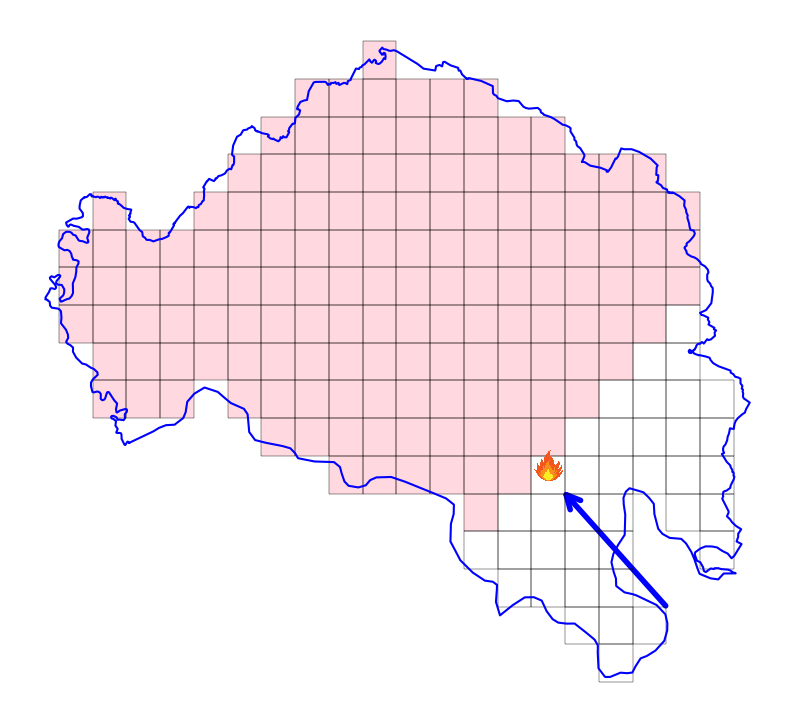

In [52]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot all Voronoi cells (this will be under the selected cell)
sel_grids.boundary.plot(ax=ax, color='black', linewidth=0.3)

# Fill the cells above or touching the line with orange color and alpha = 0.6
sel_grids[sel_grids['above_or_touches_line']] \
                .plot(ax=ax, color='pink', alpha=0.6, antialiased=False)

# Plot the polygon boundary
sel_polygon.boundary.plot(ax=ax, color='blue', linewidth=1.5)

# Add an arrow pointing to the selected cell, with increased thickness and size
arrow = FancyArrowPatch(posA=arrow_start, posB=arrow_end, arrowstyle='->',
                        color='blue', mutation_scale=25, lw=4)  # Increased mutation_scale and linewidth (lw)
ax.add_patch(arrow)

# Insert the fire icon as an annotation with an OffsetImage
imagebox = offsetbox.OffsetImage(fire_icon, zoom=0.015)  # Adjust zoom for icon size
ab = offsetbox.AnnotationBbox(imagebox, (selected_centroid.x, selected_centroid.y + 0.005 ),
                              frameon=False, boxcoords="data", pad=0)
ax.add_artist(ab)


# Set title and remove axes
ax.set_title('')
ax.set_axis_off()

# Save the figure as a PNG file
# plt.savefig( f'{main}/proj_downwind/tex/paper/figures/upwind.png', dpi=300, bbox_inches='tight')
plt.savefig(f'../tex/paper/figures/upwind.png',  dpi=300, bbox_inches='tight')


plt.show()


In [ ]:
grid = gpd.read_file( f"../../proj_downwind/data_output/intermediate/1-grid-generation.shp" )
file_path = r"..\data_output\intermediate\0_master_merge_data_gen.csv"
df = pl.read_csv(file_path, ignore_errors = True)


In [ ]:
df_filtered = df.filter(
    (pl.col("month") == 3) &
    (pl.col("year") == 2013)
)

In [ ]:
grid.columns= ['id', 'split_d', 'split', 'unique_small_grid_id', 'geometry']

### Generating many plots for all the years and month

In [ ]:
df_selcols = df.select(["unique_small_grid_id", "downup_ac", 'month', 'year', 'monthyear']).to_pandas()

In [ ]:
df_selcols.monthyear.unique()

In [ ]:
val = 1

In [ ]:
gridsel = df_selcols.query(f'monthyear == {val}')

In [ ]:
import calendar

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

for val in range(1, 121):
    
    gridsel = df_selcols.query(f'monthyear == {val}')
    gridsel = gpd.GeoDataFrame(gridsel.merge(grid))
    month = gridsel.month.unique()[0]
    year = gridsel.year.unique()[0]
    month_name = calendar.month_name[month]
    text = f"{month_name}, {year}"
    

    # create a helper color‐map column
    gridsel["plot_color"] = gridsel["downup_ac"].map({0: "#8FC6FA", 1: "#032544"})
    

    fig, ax = plt.subplots(figsize=(8, 8))
    gridsel.plot(ax=ax, color=gridsel["plot_color"], edgecolor="none", linewidth=0,  antialiased=False )
    # st_sel.boundary.plot(ax=ax,color = 'black')
    # build a manual legend
    # handles = [
    #     mpatches.Patch(color="#2793F2", label="Treated"),
    #     mpatches.Patch(color="#8A9FA8", label="Control"),
    # ]
    # ax.legend(handles=handles, title="", loc="upper right", 
    #          frameon = False )

    plt.title(text)
    plt.axis("off")
    # plt.show()


    fig.savefig(f"../tex/paper/figures/maps/eventstudy_{val}.png", dpi=300, bbox_inches="tight")
    print(text)
    # plt.show()

### Map for selected months

In [ ]:
# 3. Select only the column and convert to pandas
grids_march13 = df_filtered.select(["unique_small_grid_id", "downup_ac"]).to_pandas()
grids_march13 = gpd.GeoDataFrame(grids_march13.merge(grid))

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# create a helper color‐map column
grids_march13["plot_color"] = grids_march13["downup_ac"].map({0: "#8FC6FA", 1: "#032544"})

fig, ax = plt.subplots(figsize=(8, 8))
grids_march13.plot(ax=ax, color=grids_march13["plot_color"], edgecolor="none", linewidth=0,  antialiased=False )
# st_sel.boundary.plot(ax=ax,color = 'black')
# build a manual legend
# handles = [
#     mpatches.Patch(color="#2793F2", label="Treated"),
#     mpatches.Patch(color="#8A9FA8", label="Control"),
# ]
# ax.legend(handles=handles, title="", loc="upper right", 
#          frameon = False )

plt.title("March 2013")
plt.axis("off")
plt.show()


fig.savefig("../tex/paper/figures/march2013_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
oct13 = df.filter(
    (pl.col("month") == 8) &
    (pl.col("year") == 2013)
)

In [ ]:
# 3. Select only the column and convert to pandas
grids_oct13 = oct13.select(["unique_small_grid_id", "downup_ac"]).to_pandas()
grids_oct13 = gpd.GeoDataFrame(grids_oct13.merge(grid))

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# create a helper color‐map column
grids_oct13["plot_color"] = grids_oct13["downup_ac"].map({0: "#8FC6FA", 1: "#032544"})

fig, ax = plt.subplots(figsize=(8, 8))
grids_oct13.plot(ax=ax, color=grids_oct13["plot_color"], edgecolor="none", linewidth=0,  antialiased=False )
# st_sel.boundary.plot(ax=ax,color = 'black')
# build a manual legend
# handles = [
#     mpatches.Patch(color="#2793F2", label="Treated"),
#     mpatches.Patch(color="#8A9FA8", label="Control"),
# ]
# ax.legend(handles=handles, title="", loc="upper right", 
#          frameon = False )

plt.title("October 2013")
plt.axis("off")
plt.show()


fig.savefig("../tex/paper/figures/october2013_plot.png", dpi=300, bbox_inches="tight")
plt.show()